# Rail Corrugation
## Speed and Wavelength Analysis

This notebook investigates the relationship between train speed, vibration frequency and estimated corrugation wavelength.

Objectives:
- Decode the rotational-speed sensor
- Estimate train speed for each recording
- Compare train speed across classes
- Convert vibration frequencies into spatial wavelengths
- Investigate whether wavelength-domain representations better separate corrugation classes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.signal import welch

DATA_DIR = Path("..")
TRAIN_PATH = DATA_DIR / "Train"

FS = 10000
WHEEL_DIAMETER = 0.85
TEETH = 90

labels = pd.read_csv(DATA_DIR / "Train_Labels.csv")
sample = pd.read_csv(TRAIN_PATH / "Train1.csv")
speed_col = sample.columns[0]

print(speed_col)
display(sample[speed_col].value_counts())

Rotating speed


Rotating speed
0    5001
1    4999
Name: count, dtype: int64

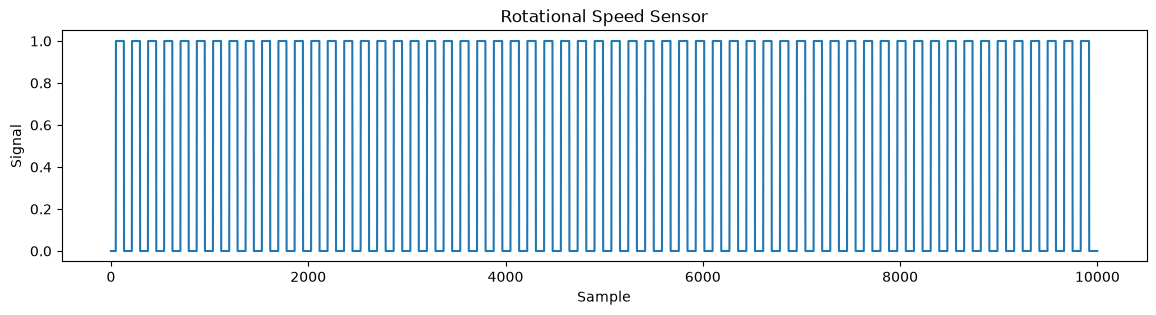

In [3]:
plt.figure(figsize=(14, 3))
plt.plot(sample[speed_col])

plt.xlabel("Sample")
plt.ylabel("Signal")
plt.title("Rotational Speed Sensor")
plt.show()

In [4]:
speed_signal = sample[speed_col].to_numpy()

transitions = np.sum(np.diff(speed_signal) != 0)

print("Transitions:", transitions)

Transitions: 118


In [5]:
teeth_passed = transitions / 2
revolutions = teeth_passed / TEETH

print("Teeth passed:", teeth_passed)
print("Wheel revolutions:", revolutions)

Teeth passed: 59.0
Wheel revolutions: 0.6555555555555556


In [6]:
circumference = np.pi * WHEEL_DIAMETER

distance = revolutions * circumference
speed_ms = distance / 1.0
speed_kmh = speed_ms * 3.6

print("Speed:", round(speed_ms, 2), "m/s")
print("Speed:", round(speed_kmh, 2), "km/h")

Speed: 1.75 m/s
Speed: 6.3 km/h


In [7]:
def estimate_speed(signal):
    transitions = np.sum(np.diff(signal) != 0)
    revolutions = (transitions / 2) / TEETH

    return revolutions * np.pi * WHEEL_DIAMETER

In [8]:
speeds = []

for _, row in labels.iterrows():
    data = pd.read_csv(TRAIN_PATH / row["filename"])

    speeds.append(
        estimate_speed(data.iloc[:, 0].to_numpy())
    )

labels["speed_ms"] = speeds
labels["speed_kmh"] = labels["speed_ms"] * 3.6

In [9]:
display(
    labels.groupby("label")["speed_kmh"].describe()
)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Normal,234.0,28.881131,21.251357,0.000000,9.586570,29.267077,46.424100,70.123490
Side I,14.0,49.454952,10.151862,34.928227,45.809919,46.651080,48.840770,66.972472
Side II,24.0,52.514732,6.921049,42.084775,47.799332,50.389575,57.172274,66.652030


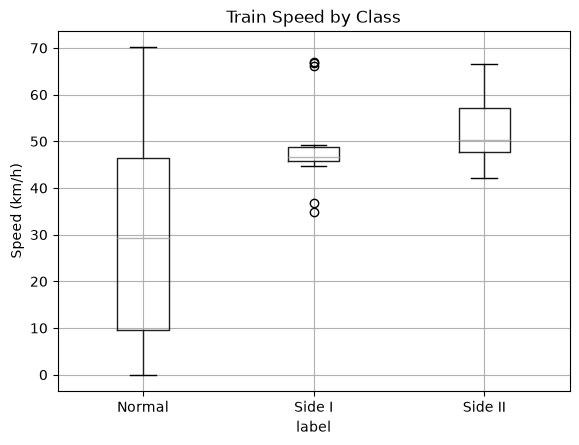

In [10]:
labels.boxplot(column="speed_kmh", by="label")

plt.ylabel("Speed (km/h)")
plt.title("Train Speed by Class")
plt.suptitle("")
plt.show()

In [11]:
signal = sample[[c for c in sample.columns if "vibration" in c.lower()][0]].to_numpy()

f, psd = welch(signal, fs=FS, nperseg=2048)

mask = f > 0

wavelength = speed_ms / f[mask]

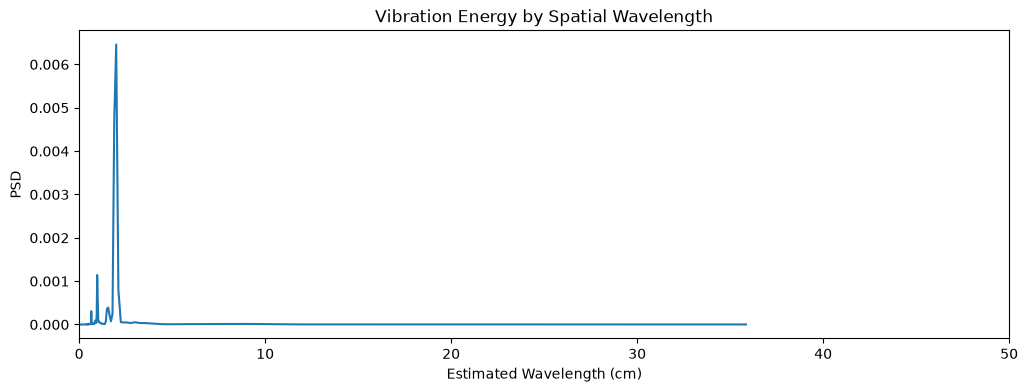

In [12]:
plt.figure(figsize=(12, 4))

plt.plot(wavelength * 100, psd[mask])
plt.xlim(0, 50)

plt.xlabel("Estimated Wavelength (cm)")
plt.ylabel("PSD")
plt.title("Vibration Energy by Spatial Wavelength")
plt.show()

## Speed-Only Baseline

The class distributions show a substantial relationship between train speed and the training labels.

A speed-only classifier is evaluated to determine how much predictive information is contained in this operating condition alone.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

X_speed = labels[["speed_kmh"]]
y = labels["label"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

speed_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

In [14]:
speed_scores = cross_val_score(
    speed_model,
    X_speed,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Fold scores:", speed_scores.round(3))
print("Mean Macro F1:", speed_scores.mean().round(3))

Fold scores: [0.472 0.355 0.418 0.292 0.395]
Mean Macro F1: 0.386


In [15]:
features = pd.read_csv(DATA_DIR / "rail_features.csv")

X_base = features.drop(columns=["filename", "label"])
X_speed_base = X_base.copy()

X_speed_base["speed_kmh"] = labels["speed_kmh"]

In [16]:
base_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

speed_base_scores = cross_val_score(
    base_model,
    X_speed_base,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Baseline + Speed:", speed_base_scores.round(3))
print("Mean Macro F1:", speed_base_scores.mean().round(3))

Baseline + Speed: [0.642 0.628 0.723 0.73  0.685]
Mean Macro F1: 0.681
